# Portfolio edition

Original Group 4 capstone notebook by the project team; Data/ML Lead: Said Huner. Paths have been made relative to the repository. Saved results are from the original run. See `../docs/artifact-versions.md` for the difference between this notebook and the later final report.


In [ ]:
from pathlib import Path
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "requirements.txt").is_file() and (p / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the project folder.")
from IPython.display import display


# Assignment 4 – Solution Development  
## Hotel Booking Cancellation Prediction

**Course:** BIA 5450 Capstone  
**Team:** Group 4  
**Data/ML Lead:** Said Huner  

### Purpose

This notebook implements the machine-learning solution designed in Assignment 3. It uses the model-ready dataset prepared in Assignment 2 to train and compare cancellation-prediction models, generate cancellation probabilities, calculate Revenue at Risk, create a ranked action list, test business scenarios, and optimize the final model.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paths
DATA_PATH = PROJECT_ROOT / "outputs/data_preparation/hotel_bookings_model_ready.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "outputs/modeling"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# Load model-ready dataset from Assignment 2
df = pd.read_csv(DATA_PATH)

# Parse arrival date
df["arrival_date"] = pd.to_datetime(df["arrival_date"], errors="coerce")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Dataset loaded successfully.
Rows: 118,563
Columns: 37


,booking_id,arrival_date,is_canceled,hotel,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,is_family,has_agent,has_company,zero_adr_flag,booking_value,arrival_season,arrival_quarter,arrival_year_month,lead_time_group,adr_group
0,HB000003,2015-07-01,0,Resort Hotel,7,27,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,0,Transient,75.0000,0,0,1,1,0,0,0,0,75.0000,Summer,Q3,2015-07,0-7 days,1-75
1,HB000004,2015-07-01,0,Resort Hotel,13,27,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,304,Transient,75.0000,0,0,1,1,0,1,0,0,75.0000,Summer,Q3,2015-07,8-30 days,1-75
2,HB000005,2015-07-01,0,Resort Hotel,14,27,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240,Transient,98.0000,0,1,2,2,0,1,0,0,196.0000,Summer,Q3,2015-07,8-30 days,76-125
3,HB000006,2015-07-01,0,Resort Hotel,14,27,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240,Transient,98.0000,0,1,2,2,0,1,0,0,196.0000,Summer,Q3,2015-07,8-30 days,76-125
4,HB000007,2015-07-01,0,Resort Hotel,0,27,0,2,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,0,Transient,107.0000,0,0,2,2,0,0,0,0,214.0000,Summer,Q3,2015-07,0-7 days,76-125


In [2]:
print("DATASET INFO")
print("-" * 50)
df.info()

print("\nMissing values:")
print(df.isna().sum().sum())

print("\nTarget distribution:")
target_summary = (
    df["is_canceled"]
    .value_counts()
    .sort_index()
    .rename_axis("is_canceled")
    .reset_index(name="booking_count")
)

target_summary["status"] = target_summary["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

target_summary["percentage"] = (
    target_summary["booking_count"] / len(df) * 100
).round(2)

display(target_summary)

DATASET INFO
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118563 entries, 0 to 118562
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   booking_id                      118563 non-null  object        
 1   arrival_date                    118563 non-null  datetime64[ns]
 2   is_canceled                     118563 non-null  int64         
 3   hotel                           118563 non-null  object        
 4   lead_time                       118563 non-null  int64         
 5   arrival_date_week_number        118563 non-null  int64         
 6   stays_in_weekend_nights         118563 non-null  int64         
 7   stays_in_week_nights            118563 non-null  int64         
 8   adults                          118563 non-null  int64         
 9   children                        118563 non-null  int64       

,is_canceled,booking_count,status,percentage
0,0,74388,Not Canceled,62.7400
1,1,44175,Canceled,37.2600


The Assignment 4 implementation uses the model-ready dataset prepared in Assignment 2. This dataset already excludes target-leakage fields and post-booking fields, which supports the business requirement of predicting cancellation probability using booking-time information only.

In [3]:
# Sort by arrival date for temporal split
df_sorted = df.sort_values("arrival_date").reset_index(drop=True)

# Target
target_column = "is_canceled"

# Columns not used as model features
excluded_columns = [
    "booking_id",      # identifier only
    "is_canceled",    # target
    "arrival_date"    # used for temporal split, not direct model feature
]

feature_columns = [
    col for col in df_sorted.columns
    if col not in excluded_columns
]

X = df_sorted[feature_columns].copy()
y = df_sorted[target_column].copy()

# 80/20 temporal split
split_index = int(len(df_sorted) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = df_sorted["arrival_date"].iloc[:split_index]
test_dates = df_sorted["arrival_date"].iloc[split_index:]

print("Temporal split completed.")
print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows: {X_test.shape[0]:,}")
print(f"Training date range: {train_dates.min().date()} to {train_dates.max().date()}")
print(f"Testing date range: {test_dates.min().date()} to {test_dates.max().date()}")

print("\nTraining cancellation rate:")
print(f"{y_train.mean() * 100:.2f}%")

print("\nTesting cancellation rate:")
print(f"{y_test.mean() * 100:.2f}%")

Temporal split completed.
Training rows: 94,850
Testing rows: 23,713
Training date range: 2015-07-01 to 2017-04-23
Testing date range: 2017-04-23 to 2017-08-31

Training cancellation rate:
36.34%

Testing cancellation rate:
40.93%


# 4. Identify numerical and categorical columns

In [4]:
numeric_columns = X_train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print(f"Numeric columns: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nCategorical columns: {len(categorical_columns)}")
print(categorical_columns)

Numeric columns: 21
['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'agent', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'is_family', 'has_agent', 'has_company', 'zero_adr_flag', 'booking_value']

Categorical columns: 13
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'arrival_quarter', 'arrival_year_month', 'lead_time_group', 'adr_group']


# 5. Build preprocessing pipelines

We will use two preprocessing approaches:

Logistic Regression: one-hot encoding + scaling
Tree models: ordinal encoding, which is faster and easier for Random Forest / Gradient Boosting

In [5]:
# Compatibility helper for different scikit-learn versions
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


# Preprocessing for Logistic Regression
numeric_transformer_logistic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_logistic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder())
])

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logistic, numeric_columns),
        ("cat", categorical_transformer_logistic, categorical_columns)
    ]
)


# Preprocessing for tree-based models
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_columns),
        ("cat", categorical_transformer_tree, categorical_columns)
    ]
)

print("Preprocessing pipelines created.")

Preprocessing pipelines created.


# 6.Define evaluation function

In [6]:
def evaluate_model(model_name, fitted_pipeline, X_test, y_test, training_time_seconds):
    """
    Evaluate a fitted classification model and return a dictionary of metrics.
    """

    y_pred = fitted_pipeline.predict(X_test)

    if hasattr(fitted_pipeline, "predict_proba"):
        y_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = fitted_pipeline.decision_function(X_test)

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "training_time_seconds": training_time_seconds
    }

    return metrics, y_pred, y_proba

# 7. Train initial models

In [7]:
initial_models = {
    "Logistic Regression Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor_logistic),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "Random Forest Default": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting Default": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ])
}

initial_results = []
initial_predictions = {}

for model_name, pipeline in initial_models.items():
    print(f"Training: {model_name}")

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time

    metrics, y_pred, y_proba = evaluate_model(
        model_name=model_name,
        fitted_pipeline=pipeline,
        X_test=X_test,
        y_test=y_test,
        training_time_seconds=training_time
    )

    initial_results.append(metrics)

    initial_predictions[model_name] = {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    print(f"Completed: {model_name}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"F1-score: {metrics['f1_score']:.4f}")
    print("-" * 60)

initial_results_df = pd.DataFrame(initial_results)
initial_results_df = initial_results_df.sort_values("roc_auc", ascending=False)

display(initial_results_df)

initial_results_df.to_csv(
    OUTPUT_FOLDER / "initial_model_comparison.csv",
    index=False
)

Training: Logistic Regression Baseline


[local project path]
  warnings.warn(msg, category=FutureWarning)
[local project path]
  warnings.warn(


Completed: Logistic Regression Baseline
ROC-AUC: 0.8577
F1-score: 0.7238
------------------------------------------------------------
Training: Random Forest Default
Completed: Random Forest Default
ROC-AUC: 0.8249
F1-score: 0.5279
------------------------------------------------------------
Training: Gradient Boosting Default
Completed: Gradient Boosting Default
ROC-AUC: 0.7995
F1-score: 0.4894
------------------------------------------------------------


,model_name,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Logistic Regression Baseline,0.7735,0.7226,0.7250,0.7238,0.8577,98.0995
1,Random Forest Default,0.7230,0.8730,0.3783,0.5279,0.8249,13.7952
2,Gradient Boosting Default,0.7142,0.9111,0.3345,0.4894,0.7995,7.9088


# 8. Confusion matrices for initial models

In [8]:
confusion_outputs = []

for model_name, prediction_info in initial_predictions.items():
    cm = confusion_matrix(y_test, prediction_info["y_pred"])

    tn, fp, fn, tp = cm.ravel()

    confusion_outputs.append({
        "model_name": model_name,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

confusion_df = pd.DataFrame(confusion_outputs)

display(confusion_df)

confusion_df.to_csv(
    OUTPUT_FOLDER / "initial_confusion_matrices.csv",
    index=False
)

,model_name,true_negative,false_positive,false_negative,true_positive
0,Logistic Regression Baseline,11305,2702,2669,7037
1,Random Forest Default,13473,534,6034,3672
2,Gradient Boosting Default,13690,317,6459,3247


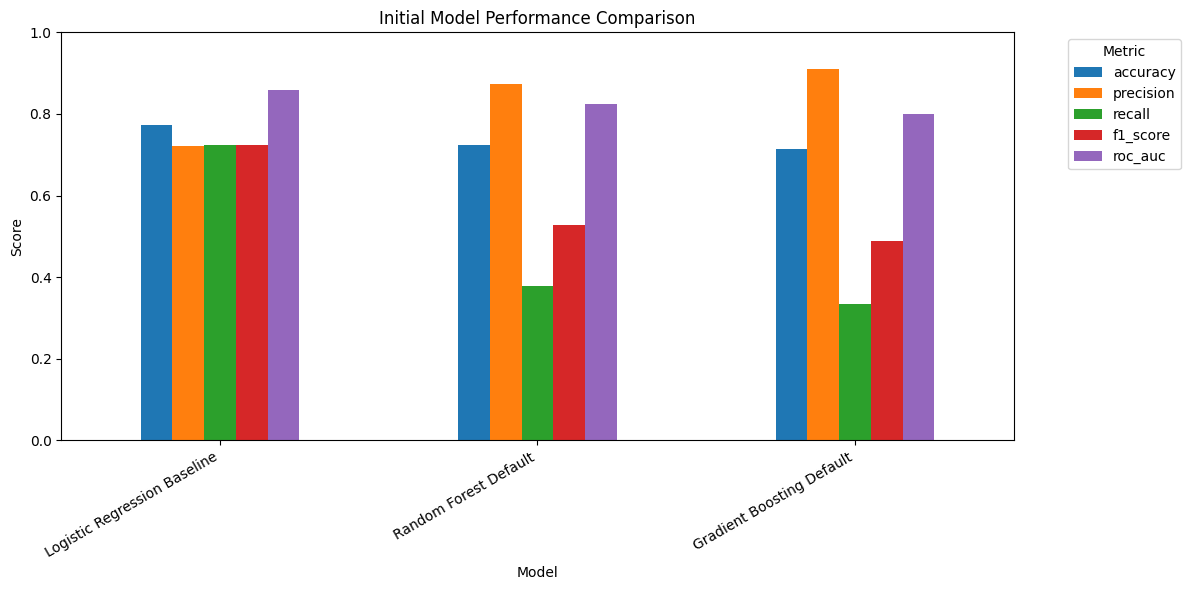

In [9]:
# Model comparison chart for key metrics

metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

model_comparison_plot = initial_results_df.set_index("model_name")[metrics_to_plot]

ax = model_comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Initial Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "initial_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

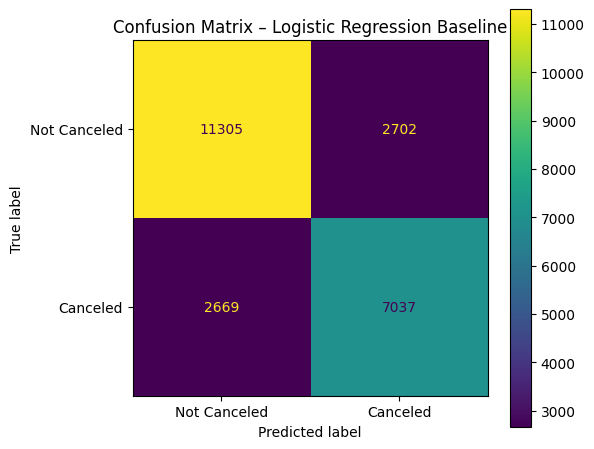

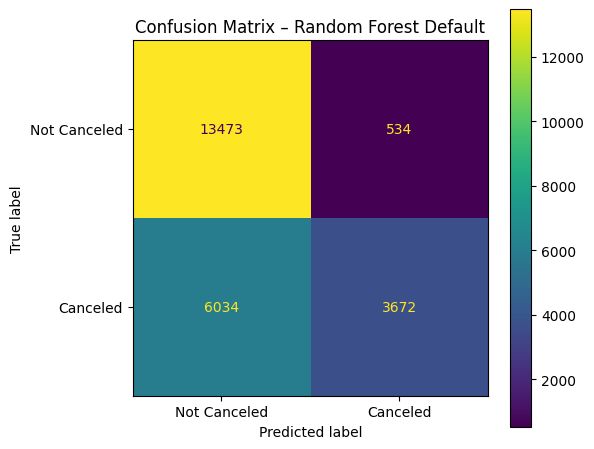

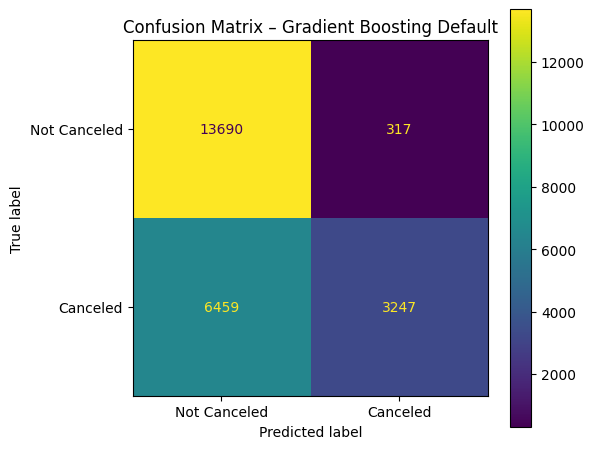

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, prediction_info in initial_predictions.items():
    
    cm = confusion_matrix(
        y_test,
        prediction_info["y_pred"]
    )

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Canceled", "Canceled"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    cm_display.plot(ax=ax, values_format="d")
    
    plt.title(f"Confusion Matrix – {model_name}")
    plt.tight_layout()

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    plt.savefig(
        OUTPUT_FOLDER / f"confusion_matrix_{safe_model_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

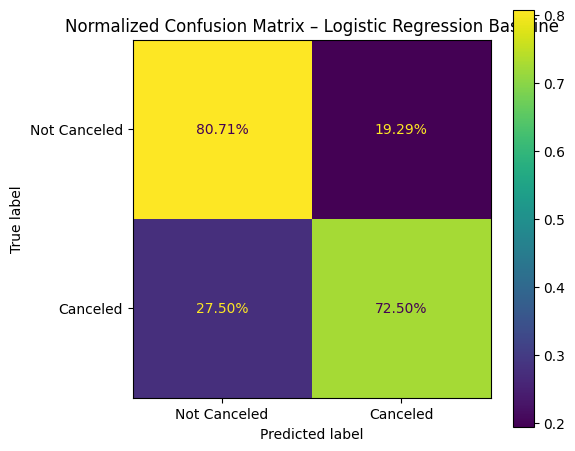

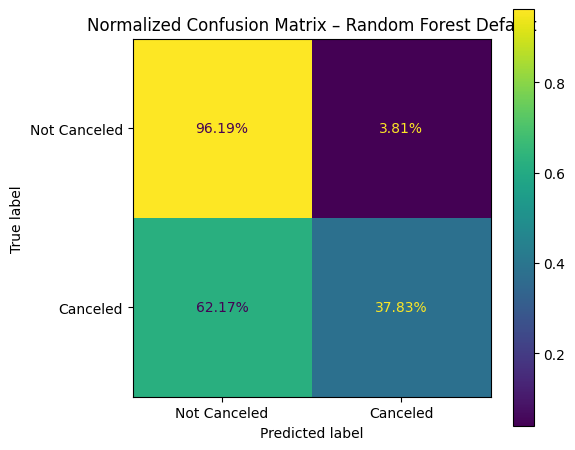

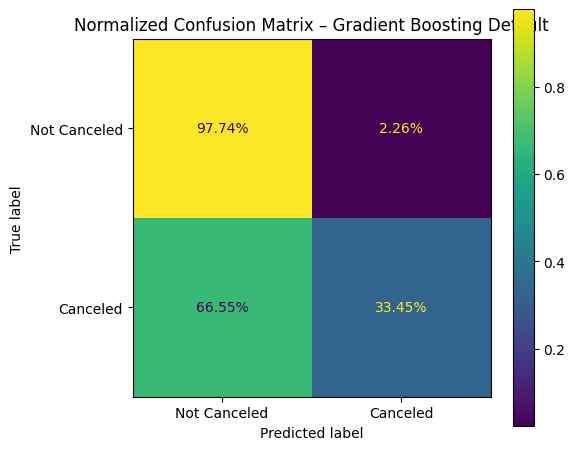

In [11]:
for model_name, prediction_info in initial_predictions.items():
    
    cm_normalized = confusion_matrix(
        y_test,
        prediction_info["y_pred"],
        normalize="true"
    )

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=["Not Canceled", "Canceled"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    cm_display.plot(ax=ax, values_format=".2%")
    
    plt.title(f"Normalized Confusion Matrix – {model_name}")
    plt.tight_layout()

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    plt.savefig(
        OUTPUT_FOLDER / f"normalized_confusion_matrix_{safe_model_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Initial Model Comparison Interpretation

Three initial classification approaches were tested: Logistic Regression, Random Forest, and Gradient Boosting. Logistic Regression was used as the baseline because it is easier to explain and supports the project requirement for interpretability. Random Forest and Gradient Boosting were tested as tree-based alternatives because they can capture non-linear relationships among booking characteristics.

The Logistic Regression baseline produced the best initial ROC-AUC score at 0.8577. It also produced the strongest F1-score at 0.7238, with balanced precision and recall. This means it was better at ranking cancellation risk and identifying canceled bookings than the default tree-based models.

The default Random Forest and Gradient Boosting models produced higher precision but much lower recall. This means that when they predicted a cancellation, they were often correct, but they missed many actual cancellations. For a hotel revenue-management use case, missing many cancellations is risky because the revenue manager needs to identify bookings that may cause future revenue loss.

Based on the initial results, Logistic Regression is the strongest baseline model. However, Assignment 4 also requires optimization, so the next step is to tune the Random Forest and Gradient Boosting models and compare them against the baseline.

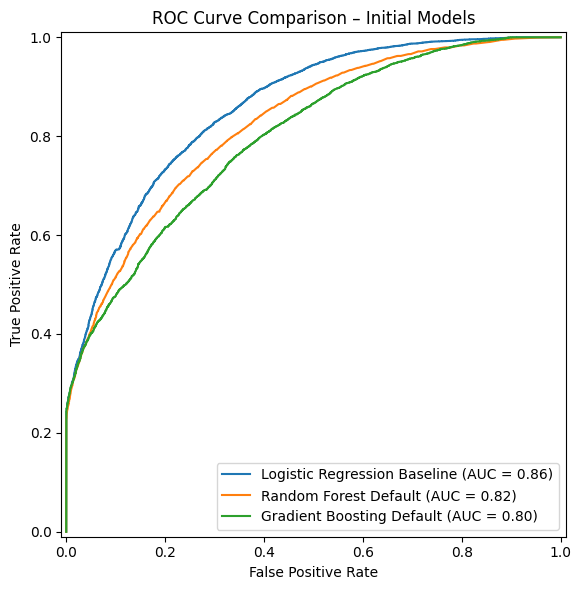

In [12]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, prediction_info in initial_predictions.items():
    RocCurveDisplay.from_predictions(
        y_test,
        prediction_info["y_proba"],
        name=model_name,
        ax=ax
    )

plt.title("ROC Curve Comparison – Initial Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "roc_curve_initial_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC Curve Interpretation

The ROC curve compares how well each model separates canceled bookings from non-canceled bookings across different classification thresholds. This is important because the project needs cancellation probabilities, not only a fixed yes-or-no prediction.

The Logistic Regression baseline produced the highest initial ROC-AUC score, which means it ranked cancellation risk more effectively than the default Random Forest and Gradient Boosting models. This supports keeping Logistic Regression as the baseline model while optimization is performed on the tree-based models.

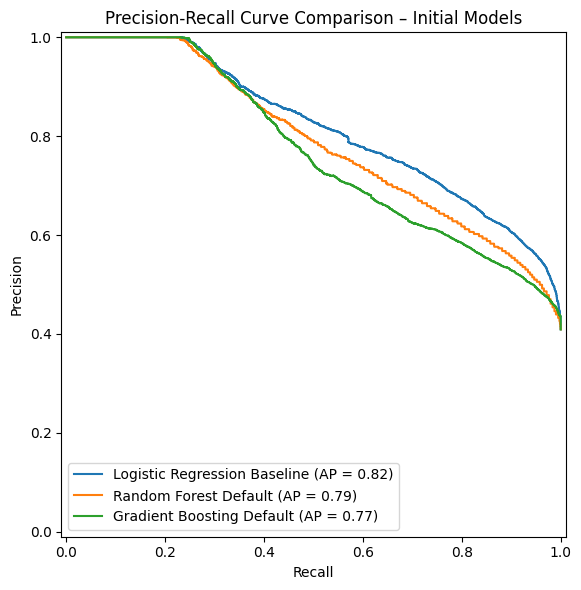

In [13]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, prediction_info in initial_predictions.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        prediction_info["y_proba"],
        name=model_name,
        ax=ax
    )

plt.title("Precision-Recall Curve Comparison – Initial Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "precision_recall_curve_initial_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Precision-Recall Curve Interpretation

The precision-recall curve is useful for this project because cancellation prediction involves a trade-off between false alarms and missed cancellations. High precision means the model is usually correct when it flags a booking as risky. High recall means the model catches more of the bookings that will actually cancel.

For revenue management, recall is important because missed cancellations can lead to lost revenue. However, precision is also important because too many false alarms could cause unnecessary customer contact or deposit requests. The best model should balance both, not maximize only one metric.

# Model Optimization

This section improves the initial models by tuning Random Forest and Gradient Boosting. The goal is to test whether optimized tree-based models can outperform the Logistic Regression baseline. The optimized models are compared using ROC-AUC, precision, recall, F1-score, accuracy, and training time.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

## Tune Random Forest

This is not too heavy. It is a controlled search.

In [15]:
# Random Forest tuning pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

start_time = time.time()

rf_search.fit(X_train, y_train)

rf_training_time = time.time() - start_time

print("Random Forest tuning completed.")
print(f"Best ROC-AUC from CV: {rf_search.best_score_:.4f}")
print("Best parameters:")
print(rf_search.best_params_)
print(f"Training time: {rf_training_time:.2f} seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=3, model__min_samples_split=5, model__n_estimators=150; total time=   6.1s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=3, model__min_samples_split=5, model__n_estimators=150; total time=   6.1s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=3, model__min_samples_split=5, model__n_estimators=150; total time=   6.8s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=150; total time=   6.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=150; total time=   6.1s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=150; total time=  

In [19]:
display(pd.DataFrame([rf_tuned_metrics]))

,model_name,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Random Forest Tuned,0.7448,0.8426,0.4629,0.5976,0.8555,240.3012


In [20]:
print("Best Random Forest CV ROC-AUC:")
print(round(rf_search.best_score_, 4))

print("\nBest Random Forest Parameters:")
for param, value in rf_search.best_params_.items():
    print(f"{param}: {value}")

Best Random Forest CV ROC-AUC:
0.8842

Best Random Forest Parameters:
model__n_estimators: 150
model__min_samples_split: 10
model__min_samples_leaf: 3
model__max_features: sqrt
model__max_depth: 10


In [21]:
rf_best_params_df = pd.DataFrame(
    list(rf_search.best_params_.items()),
    columns=["parameter", "best_value"]
)

rf_best_params_df.to_csv(
    OUTPUT_FOLDER / "random_forest_best_parameters.csv",
    index=False
)

display(rf_best_params_df)

,parameter,best_value
0,model__n_estimators,150
1,model__min_samples_split,10
2,model__min_samples_leaf,3
3,model__max_features,sqrt
4,model__max_depth,10


## Tune Gradient Boosting

In [23]:
# Gradient Boosting tuning pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", HistGradientBoostingClassifier(
        random_state=42
    ))
])

gb_param_grid = {
    "model__max_iter": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__min_samples_leaf": [20, 50, 100]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

start_time = time.time()

gb_search.fit(X_train, y_train)

gb_training_time = time.time() - start_time

print("Gradient Boosting tuning completed.")
print(f"Best ROC-AUC from CV: {gb_search.best_score_:.4f}")
print("Best parameters:")
print(gb_search.best_params_)
print(f"Training time: {gb_training_time:.2f} seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=300, model__max_leaf_nodes=63, model__min_samples_leaf=20; total time=   8.4s
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=300, model__max_leaf_nodes=63, model__min_samples_leaf=20; total time=   8.4s
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=300, model__max_leaf_nodes=63, model__min_samples_leaf=20; total time=   8.3s
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=100, model__max_leaf_nodes=63, model__min_samples_leaf=20; total time=   3.4s
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=100, model__max_leaf_nodes=63, model__min_samples_leaf=20; total time=   3.7s
[CV] END model__l2_regularization=0.0, model__learning_rate=0.03, model__max_iter=100, model__max_leaf_nodes=63, model__min_samples_leaf=20

In [25]:
gb_tuned_metrics, gb_tuned_pred, gb_tuned_proba = evaluate_model(
    model_name="Gradient Boosting Tuned",
    fitted_pipeline=gb_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    training_time_seconds=gb_training_time
)

display(pd.DataFrame([gb_tuned_metrics]))

,model_name,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Gradient Boosting Tuned,0.7196,0.8963,0.3562,0.5098,0.8211,181.7340


## Combine initial and tuned model results

In [26]:
optimized_results_df = pd.concat(
    [
        initial_results_df,
        pd.DataFrame([
            rf_tuned_metrics,
            gb_tuned_metrics
        ])
    ],
    ignore_index=True
)

optimized_results_df = optimized_results_df.sort_values(
    "roc_auc",
    ascending=False
).reset_index(drop=True)

display(optimized_results_df)

optimized_results_df.to_csv(
    OUTPUT_FOLDER / "optimized_model_comparison.csv",
    index=False
)

,model_name,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Logistic Regression Baseline,0.7735,0.7226,0.7250,0.7238,0.8577,98.0995
1,Random Forest Tuned,0.7448,0.8426,0.4629,0.5976,0.8555,240.3012
2,Random Forest Default,0.7230,0.8730,0.3783,0.5279,0.8249,13.7952
3,Gradient Boosting Tuned,0.7196,0.8963,0.3562,0.5098,0.8211,181.7340
4,Gradient Boosting Default,0.7142,0.9111,0.3345,0.4894,0.7995,7.9088


## Visualize optimized model comparison

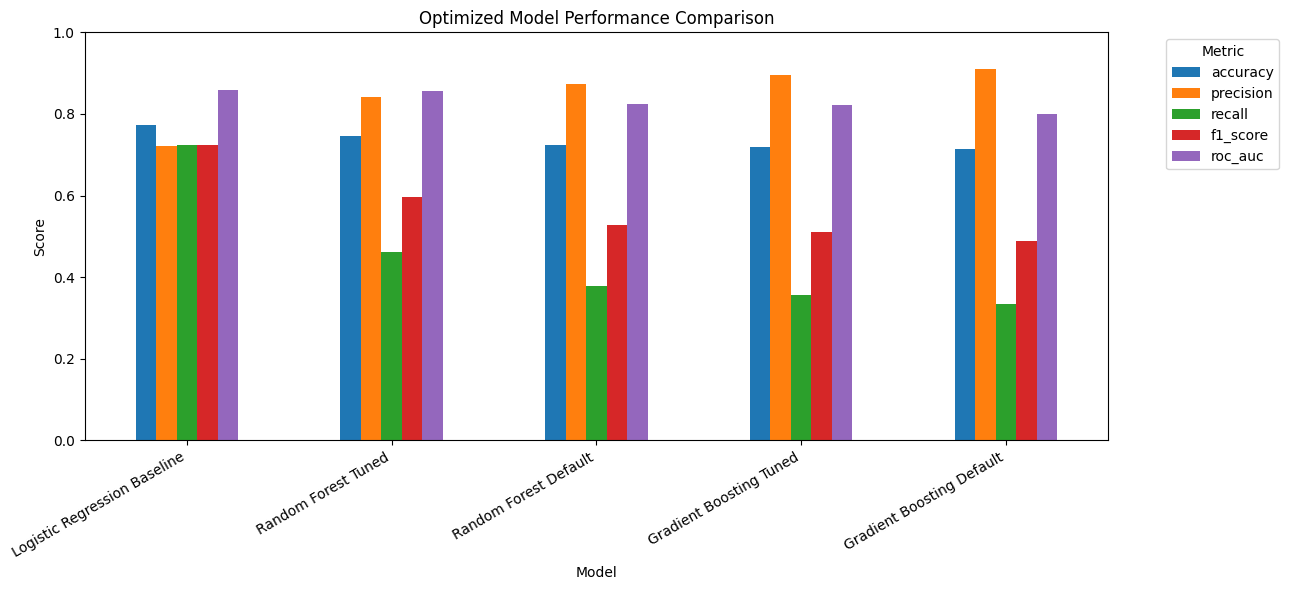

In [27]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

optimized_plot_df = optimized_results_df.set_index("model_name")[metrics_to_plot]

ax = optimized_plot_df.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Optimized Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "optimized_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Select the final model

In [28]:
best_model_name = optimized_results_df.iloc[0]["model_name"]

print(f"Best model based on ROC-AUC: {best_model_name}")

if best_model_name == "Random Forest Tuned":
    final_model = rf_search.best_estimator_
    final_y_pred = rf_tuned_pred
    final_y_proba = rf_tuned_proba

elif best_model_name == "Gradient Boosting Tuned":
    final_model = gb_search.best_estimator_
    final_y_pred = gb_tuned_pred
    final_y_proba = gb_tuned_proba

else:
    final_model = initial_predictions[best_model_name]["pipeline"]
    final_y_pred = initial_predictions[best_model_name]["y_pred"]
    final_y_proba = initial_predictions[best_model_name]["y_proba"]

final_metrics = optimized_results_df[
    optimized_results_df["model_name"] == best_model_name
].copy()

display(final_metrics)

Best model based on ROC-AUC: Logistic Regression Baseline


,model_name,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Logistic Regression Baseline,0.7735,0.7226,0.7250,0.7238,0.8577,98.0995


## Save the final model

In [29]:
joblib.dump(
    final_model,
    OUTPUT_FOLDER / "final_cancellation_model.pkl"
)

final_metrics.to_csv(
    OUTPUT_FOLDER / "final_model_metrics.csv",
    index=False
)

print("Final model and final metrics saved.")

Final model and final metrics saved.


## Final model confusion matrix

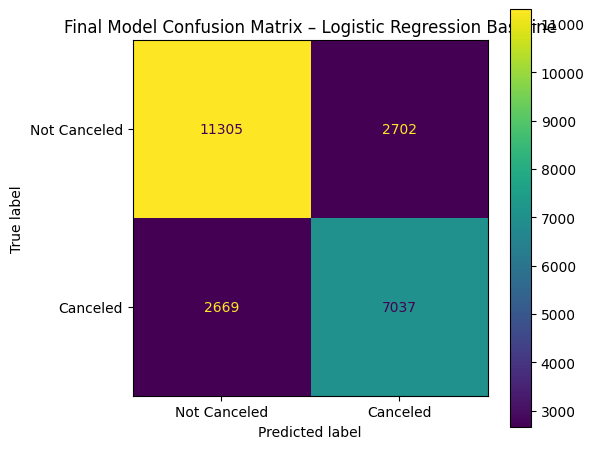

In [30]:
final_cm = confusion_matrix(y_test, final_y_pred)

final_display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Not Canceled", "Canceled"]
)

fig, ax = plt.subplots(figsize=(6, 5))
final_display.plot(ax=ax, values_format="d")

plt.title(f"Final Model Confusion Matrix – {best_model_name}")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "final_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Normalized version:

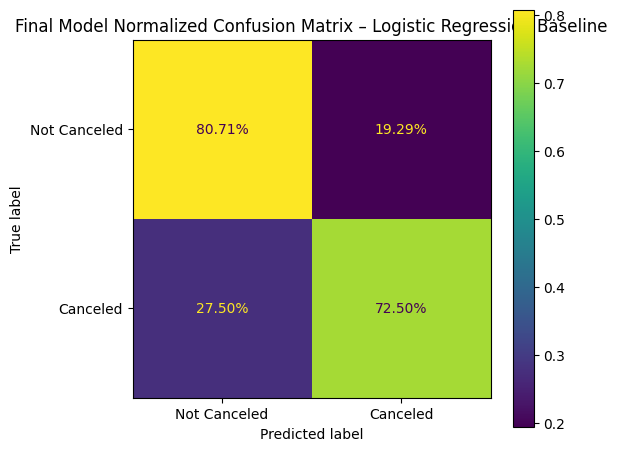

In [31]:
final_cm_normalized = confusion_matrix(
    y_test,
    final_y_pred,
    normalize="true"
)

final_display_normalized = ConfusionMatrixDisplay(
    confusion_matrix=final_cm_normalized,
    display_labels=["Not Canceled", "Canceled"]
)

fig, ax = plt.subplots(figsize=(6, 5))
final_display_normalized.plot(ax=ax, values_format=".2%")

plt.title(f"Final Model Normalized Confusion Matrix – {best_model_name}")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER / "final_model_normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Prediction Outputs and Revenue-at-Risk Action List

This section uses the selected final model to generate cancellation probabilities for the test dataset. The probabilities are converted into risk bands, Revenue at Risk, and recommended business actions for Power BI.

In [32]:
# Create prediction output for the test set

test_output = df_sorted.iloc[split_index:].copy()

test_output["cancel_probability"] = final_y_proba
test_output["predicted_cancel"] = final_y_pred

# Revenue at Risk = booking value × cancellation probability
test_output["revenue_at_risk"] = (
    test_output["booking_value"] * test_output["cancel_probability"]
).round(2)

# Risk band rules
def assign_risk_band(probability):
    if probability >= 0.85:
        return "Very High"
    elif probability >= 0.70:
        return "High"
    elif probability >= 0.50:
        return "Watch"
    else:
        return "Low"

# Recommended action rules
def assign_recommended_action(probability):
    if probability >= 0.85:
        return "Request Deposit"
    elif probability >= 0.70:
        return "Retention Offer"
    elif probability >= 0.50:
        return "Watch List"
    else:
        return "Monitor"

test_output["risk_band"] = test_output["cancel_probability"].apply(assign_risk_band)
test_output["recommended_action"] = test_output["cancel_probability"].apply(assign_recommended_action)

# Select Power BI/action-list fields
prediction_columns = [
    "booking_id",
    "arrival_date",
    "hotel",
    "country",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "lead_time",
    "total_nights",
    "total_guests",
    "adr",
    "booking_value",
    "is_canceled",
    "cancel_probability",
    "predicted_cancel",
    "risk_band",
    "revenue_at_risk",
    "recommended_action"
]

predictions_df = test_output[prediction_columns].copy()

display(predictions_df.head())

,booking_id,arrival_date,hotel,country,market_segment,distribution_channel,deposit_type,customer_type,lead_time,total_nights,total_guests,adr,booking_value,is_canceled,cancel_probability,predicted_cancel,risk_band,revenue_at_risk,recommended_action
94850,HB011152,2017-04-23,Resort Hotel,PRT,Groups,TA/TO,No Deposit,Transient-Party,31,1,1,74.0000,74.0000,1,0.5688,1,Watch,42.0900,Watch List
94851,HB066715,2017-04-23,City Hotel,FRA,Direct,Direct,No Deposit,Transient,69,4,2,145.0000,580.0000,1,0.4047,0,Low,234.7200,Monitor
94852,HB066716,2017-04-23,City Hotel,GBR,Online TA,TA/TO,No Deposit,Transient,99,4,2,108.0000,432.0000,1,0.7455,1,High,322.0600,Retention Offer
94853,HB066717,2017-04-23,City Hotel,AUS,Online TA,TA/TO,No Deposit,Transient,170,4,2,117.0000,468.0000,1,0.0972,0,Low,45.4800,Monitor
94854,HB066718,2017-04-23,City Hotel,PRT,Offline TA/TO,TA/TO,No Deposit,Transient-Party,310,4,2,75.0000,300.0000,1,0.7418,1,High,222.5500,Retention Offer


In [33]:
predictions_df.to_csv(
    OUTPUT_FOLDER / "hotel_booking_predictions.csv",
    index=False,
    date_format="%Y-%m-%d"
)

print("Prediction output saved.")

Prediction output saved.


In [34]:
action_list_df = (
    predictions_df[
        predictions_df["recommended_action"].isin([
            "Request Deposit",
            "Retention Offer",
            "Watch List"
        ])
    ]
    .sort_values(
        ["revenue_at_risk", "cancel_probability"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(action_list_df.head(25))

action_list_df.to_csv(
    OUTPUT_FOLDER / "revenue_at_risk_action_list.csv",
    index=False,
    date_format="%Y-%m-%d"
)

print(f"Action list saved with {len(action_list_df):,} bookings.")

,booking_id,arrival_date,hotel,country,market_segment,distribution_channel,deposit_type,customer_type,lead_time,total_nights,total_guests,adr,booking_value,is_canceled,cancel_probability,predicted_cancel,risk_band,revenue_at_risk,recommended_action
0,HB013143,2017-08-01,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,378,14,2,450.0000,"6,300.0000",1,0.9469,1,Very High,"5,965.6400",Request Deposit
1,HB067342,2017-05-01,City Hotel,AGO,Online TA,TA/TO,No Deposit,Transient,28,14,4,266.4300,"3,730.0200",1,0.9553,1,Very High,"3,563.4600",Request Deposit
2,HB013584,2017-08-20,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,83,19,2,204.7400,"3,890.0600",1,0.8830,1,Very High,"3,435.0400",Request Deposit
3,HB012548,2017-07-03,Resort Hotel,LUX,Online TA,TA/TO,No Deposit,Transient,277,14,4,259.8600,"3,638.0400",1,0.8490,1,High,"3,088.7900",Retention Offer
4,HB012913,2017-07-22,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,352,14,4,219.0000,"3,066.0000",1,0.9735,1,Very High,"2,984.6100",Request Deposit
5,HB013324,2017-08-09,Resort Hotel,PRT,Direct,Direct,No Deposit,Transient,116,10,3,392.0000,"3,920.0000",1,0.7483,1,High,"2,933.2400",Retention Offer
6,HB013381,2017-08-12,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,213,14,3,228.0000,"3,192.0000",1,0.8970,1,Very High,"2,863.2300",Request Deposit
7,HB013272,2017-08-06,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,45,14,3,216.0000,"3,024.0000",1,0.9417,1,Very High,"2,847.5600",Request Deposit
8,HB013761,2017-08-28,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,237,10,4,293.6000,"2,936.0000",1,0.9596,1,Very High,"2,817.5300",Request Deposit
9,HB012817,2017-07-17,Resort Hotel,PRT,Online TA,TA/TO,No Deposit,Transient,236,16,2,182.9200,"2,926.7200",1,0.9590,1,Very High,"2,806.8500",Request Deposit


Action list saved with 9,739 bookings.


In [35]:
action_summary = (
    predictions_df
    .groupby(["risk_band", "recommended_action"])
    .agg(
        booking_count=("booking_id", "count"),
        total_booking_value=("booking_value", "sum"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
        average_cancel_probability=("cancel_probability", "mean")
    )
    .reset_index()
)

action_summary["total_booking_value"] = action_summary["total_booking_value"].round(2)
action_summary["total_revenue_at_risk"] = action_summary["total_revenue_at_risk"].round(2)
action_summary["average_cancel_probability"] = action_summary["average_cancel_probability"].round(4)

display(action_summary)

action_summary.to_csv(
    OUTPUT_FOLDER / "action_summary.csv",
    index=False
)

,risk_band,recommended_action,booking_count,total_booking_value,total_revenue_at_risk,average_cancel_probability
0,High,Retention Offer,1962,"1,246,723.2200","960,150.1800",0.7696
1,Low,Monitor,13974,"6,916,890.7000","1,533,977.0300",0.2141
2,Very High,Request Deposit,3267,"1,508,455.8800","1,443,192.0200",0.9707
3,Watch,Watch List,4510,"2,433,800.6200","1,479,268.4300",0.6055


# Test Scenarios

This section tests the final model on three manually defined business scenarios. The goal is to confirm that the solution produces a cancellation probability, risk band, Revenue at Risk, and recommended action for different booking situations.

In [36]:
def create_base_scenario_row(X_reference):
    """
    Create one complete scenario row using median values for numeric columns
    and mode values for categorical columns.
    """
    row = {}

    for column in X_reference.columns:
        if column in numeric_columns:
            row[column] = X_reference[column].median()
        else:
            row[column] = X_reference[column].mode(dropna=True).iloc[0]

    return row


def apply_business_rules_to_scenario(scenario_df, probability):
    """
    Add probability, risk band, recommended action, and revenue at risk.
    """
    scenario_df = scenario_df.copy()

    scenario_df["cancel_probability"] = probability
    scenario_df["predicted_cancel"] = int(probability >= 0.50)
    scenario_df["risk_band"] = scenario_df["cancel_probability"].apply(assign_risk_band)
    scenario_df["recommended_action"] = scenario_df["cancel_probability"].apply(assign_recommended_action)
    scenario_df["revenue_at_risk"] = (
        scenario_df["booking_value"] * scenario_df["cancel_probability"]
    ).round(2)

    return scenario_df

In [37]:
base_row = create_base_scenario_row(X_train)

scenario_rows = []

# Scenario 1: Low-risk direct short-lead booking
scenario_1 = base_row.copy()
scenario_1.update({
    "hotel": "City Hotel",
    "lead_time": 3,
    "arrival_date_week_number": 20,
    "stays_in_weekend_nights": 0,
    "stays_in_week_nights": 2,
    "adults": 2,
    "children": 0,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Direct",
    "distribution_channel": "Direct",
    "is_repeated_guest": 1,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 2,
    "reserved_room_type": "A",
    "deposit_type": "No Deposit",
    "agent": 0,
    "customer_type": "Transient",
    "adr": 95,
    "required_car_parking_spaces": 1,
    "total_of_special_requests": 3,
    "total_guests": 2,
    "total_nights": 2,
    "is_family": 0,
    "has_agent": 0,
    "has_company": 0,
    "zero_adr_flag": 0,
    "booking_value": 190,
    "arrival_season": "Spring",
    "arrival_quarter": "Q2",
    "arrival_year_month": "2017-05",
    "lead_time_group": "0-7 days",
    "adr_group": "76-125"
})
scenario_rows.append(("Scenario 1 - Low-risk direct booking", scenario_1))


# Scenario 2: Medium-risk OTA booking
scenario_2 = base_row.copy()
scenario_2.update({
    "hotel": "City Hotel",
    "lead_time": 75,
    "arrival_date_week_number": 30,
    "stays_in_weekend_nights": 1,
    "stays_in_week_nights": 3,
    "adults": 2,
    "children": 0,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A",
    "deposit_type": "No Deposit",
    "agent": 9,
    "customer_type": "Transient",
    "adr": 140,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 1,
    "total_guests": 2,
    "total_nights": 4,
    "is_family": 0,
    "has_agent": 1,
    "has_company": 0,
    "zero_adr_flag": 0,
    "booking_value": 560,
    "arrival_season": "Summer",
    "arrival_quarter": "Q3",
    "arrival_year_month": "2017-07",
    "lead_time_group": "31-90 days",
    "adr_group": "126-200"
})
scenario_rows.append(("Scenario 2 - Medium-risk OTA booking", scenario_2))


# Scenario 3: High-risk long-lead booking
scenario_3 = base_row.copy()
scenario_3.update({
    "hotel": "Resort Hotel",
    "lead_time": 220,
    "arrival_date_week_number": 33,
    "stays_in_weekend_nights": 2,
    "stays_in_week_nights": 5,
    "adults": 2,
    "children": 1,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "is_repeated_guest": 0,
    "previous_cancellations": 1,
    "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A",
    "deposit_type": "No Deposit",
    "agent": 9,
    "customer_type": "Transient",
    "adr": 210,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 0,
    "total_guests": 3,
    "total_nights": 7,
    "is_family": 1,
    "has_agent": 1,
    "has_company": 0,
    "zero_adr_flag": 0,
    "booking_value": 1470,
    "arrival_season": "Summer",
    "arrival_quarter": "Q3",
    "arrival_year_month": "2017-08",
    "lead_time_group": "181-365 days",
    "adr_group": "201+"
})
scenario_rows.append(("Scenario 3 - High-risk long-lead booking", scenario_3))

In [38]:
scenario_results = []

for scenario_name, scenario_data in scenario_rows:
    scenario_df = pd.DataFrame([scenario_data])

    # Ensure same column order as training features
    scenario_df = scenario_df[feature_columns]

    probability = final_model.predict_proba(scenario_df)[0, 1]

    scored_scenario = apply_business_rules_to_scenario(
        scenario_df,
        probability
    )

    scored_scenario.insert(0, "scenario_name", scenario_name)

    scenario_results.append(scored_scenario)

test_scenarios_results = pd.concat(
    scenario_results,
    ignore_index=True
)

display(test_scenarios_results[
    [
        "scenario_name",
        "hotel",
        "lead_time",
        "market_segment",
        "distribution_channel",
        "deposit_type",
        "adr",
        "total_nights",
        "booking_value",
        "cancel_probability",
        "predicted_cancel",
        "risk_band",
        "revenue_at_risk",
        "recommended_action"
    ]
])

,scenario_name,hotel,lead_time,market_segment,distribution_channel,deposit_type,adr,total_nights,booking_value,cancel_probability,predicted_cancel,risk_band,revenue_at_risk,recommended_action
0,Scenario 1 - Low-risk direct booking,City Hotel,3,Direct,Direct,No Deposit,95,2,190,0.0000,0,Low,0.0000,Monitor
1,Scenario 2 - Medium-risk OTA booking,City Hotel,75,Online TA,TA/TO,No Deposit,140,4,560,0.8573,1,Very High,480.1100,Request Deposit
2,Scenario 3 - High-risk long-lead booking,Resort Hotel,220,Online TA,TA/TO,No Deposit,210,7,1470,0.9960,1,Very High,"1,464.1200",Request Deposit


In [39]:
test_scenarios_results.to_csv(
    OUTPUT_FOLDER / "test_scenarios_results.csv",
    index=False
)

print("Test scenario results saved.")

Test scenario results saved.


## Test Scenario Interpretation

Three business test scenarios were created to verify that the final model and business rules work together. The first scenario represents a short-lead direct booking with repeated-guest behaviour and special requests. This type of booking is expected to receive a lower cancellation-risk score and a monitor-type action.

The second scenario represents an Online Travel Agent booking with moderate lead time and no deposit. This tests whether the solution identifies a booking that may require closer monitoring or retention action.

The third scenario represents a long-lead summer booking through an Online Travel Agent with no deposit and a higher booking value. This scenario tests whether the system can flag a booking with higher revenue exposure and recommend a stronger business action.

The test scenarios confirm that the solution produces the required outputs for each booking: cancellation probability, predicted cancellation class, risk band, Revenue at Risk, and recommended action. 